In [3]:
import tensorflow as tf
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from tensorflow.python.keras.optimizers import *
import numpy as np
from sklearn import datasets
iris = datasets.load_iris()
#print(iris)


In [21]:
#Load dataset
#split into input (X) and output (y)
#X = np.array([[1], [4], [9], [16], [25], [36], [49], [64], [81], [100]])
X = iris.data[:,0]
#X = X*1.0
#y = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = iris.data[:,2]
#y = y*1.0

#define keras model
model = Sequential()

model.add(Dense(8,input_dim=1,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1))

#compile the keras model
opt = optimizers.Adam(learning_rate=0.001)
mse = tf.keras.losses.MeanSquaredError(
    reduction=tf.keras.losses.Reduction.SUM)
model.compile(loss=mse, optimizer=opt)



#fit the keras model on the dataset (CPU)
model.fit(X,y,epochs=2000,batch_size=10, verbose=0)
model.summary()

#make class predictions with the model
predictions = model.predict(X)

#summarize the first 10 cases
for i in range(10):
    print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.76 KB)

 Trainable params: 149 (596.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 300 (1.18 KB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5.1 => 2.14 (expected 1.40)
4.9 => 1.85 (expected 1.40)
4.7 => 1.56 (expected 1.30)
4.6 => 1.42 (expected 1.50)
5.0 => 1.99 (expected 1.40)
5.4 => 2.90 (expected 1.70)
4.6 => 1.42 (expected 1.40)
5.0 => 1.99 (expected 1.50)
4.4 => 1.13 (expected 1.40)
4.9 => 1.85 (expected 1.50)


/tmp/ipython-input-951885999.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )


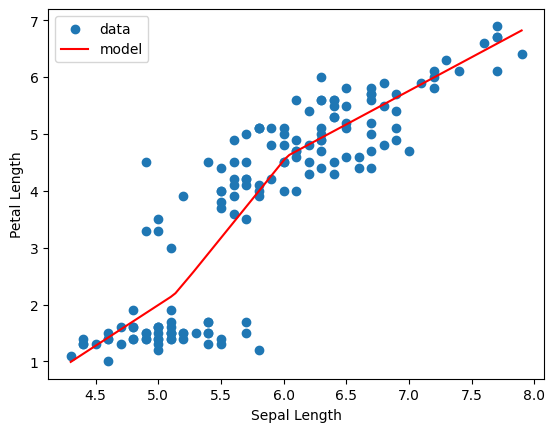

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

number_grid = np.linspace(X.min(), X.max(), 100)
prediction_grid = model(number_grid, training=False).numpy()

plt.scatter(X, y, label='data')
plt.plot(number_grid, prediction_grid, color='red', label='model')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()